# 多层感知机

## 感知机

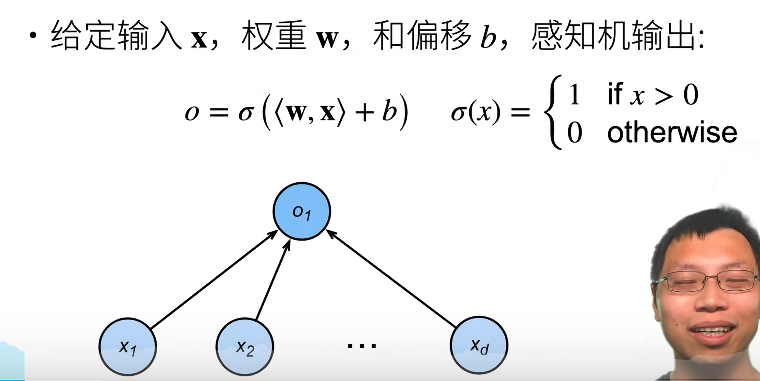

感知机输入x1,x2...，输出1或0（二分类）
- 回归输出实数
- softmax输出概率

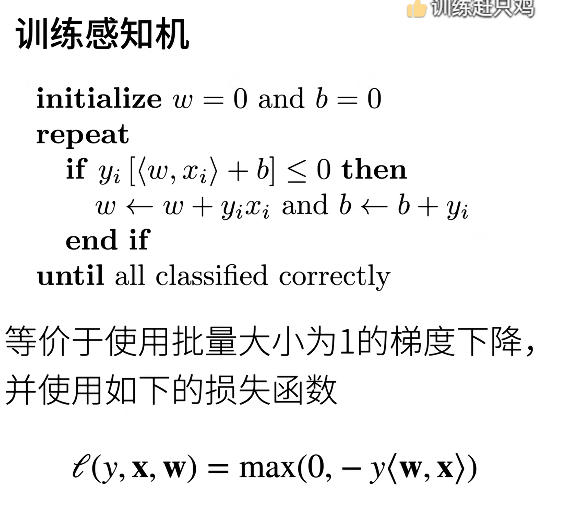

训练感知机：  
分类错误的样本更新权重和偏置，类似于对错误样本做梯度下降

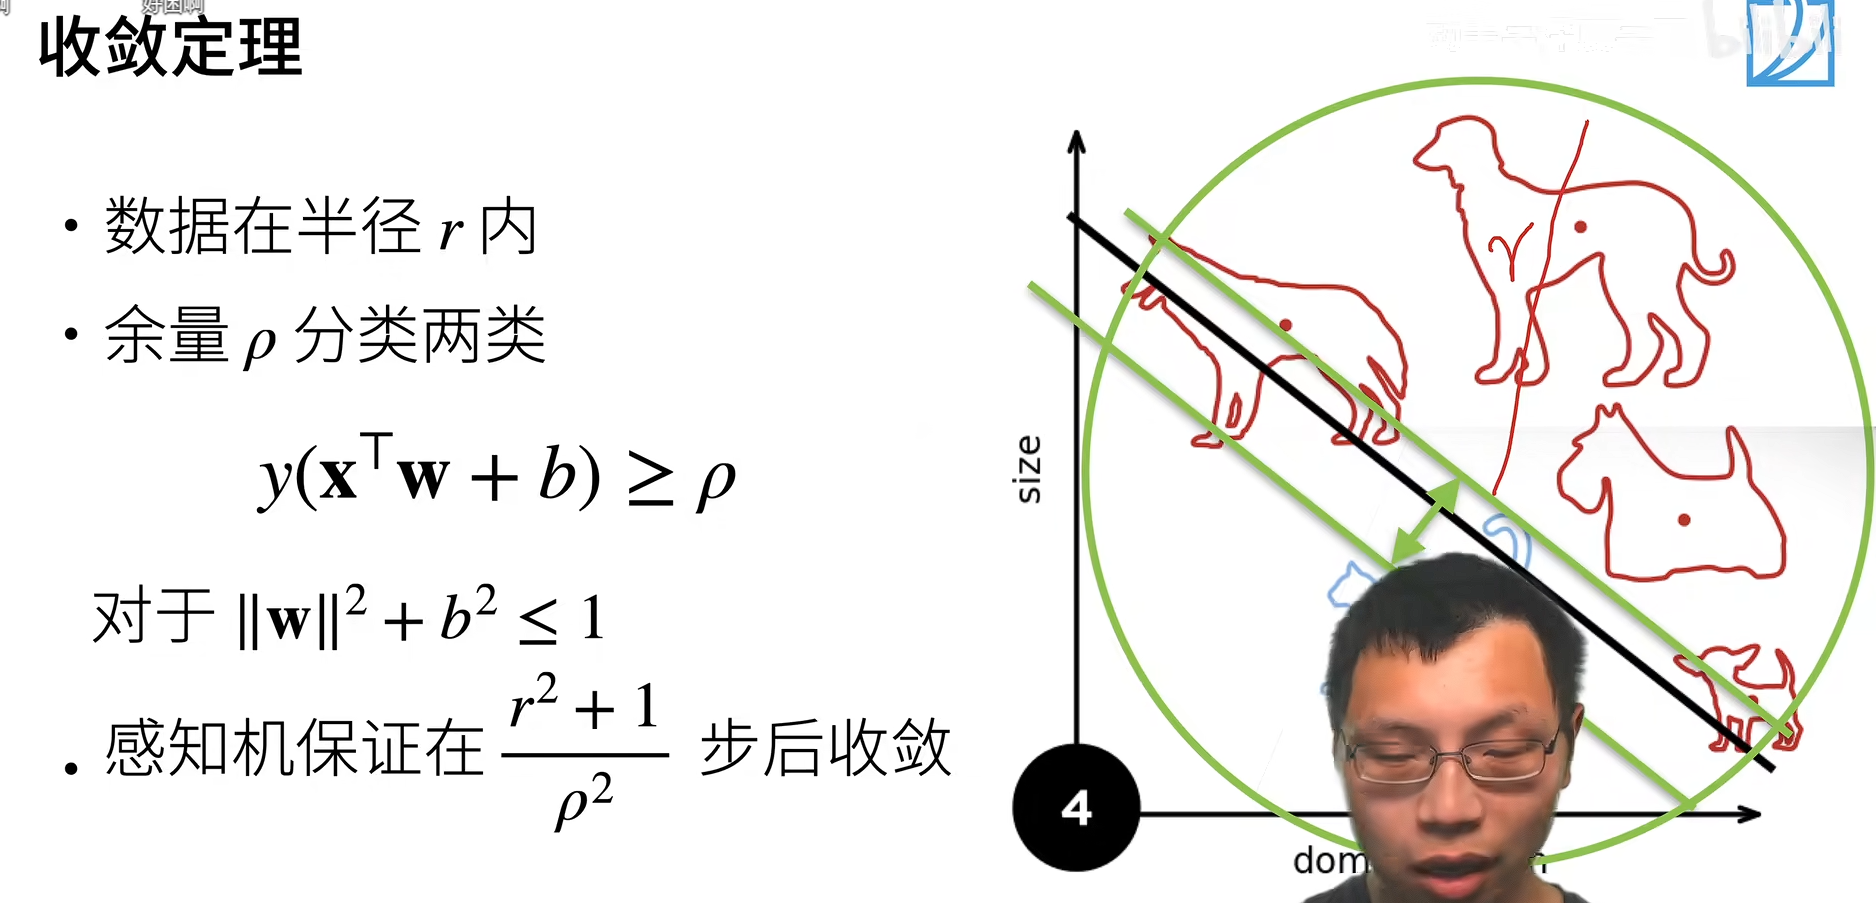

XOR问题：   
感知机不能拟合XOR函数，它只能产生线性分割面

## 多层感知机

### 单隐藏层——单分类：  
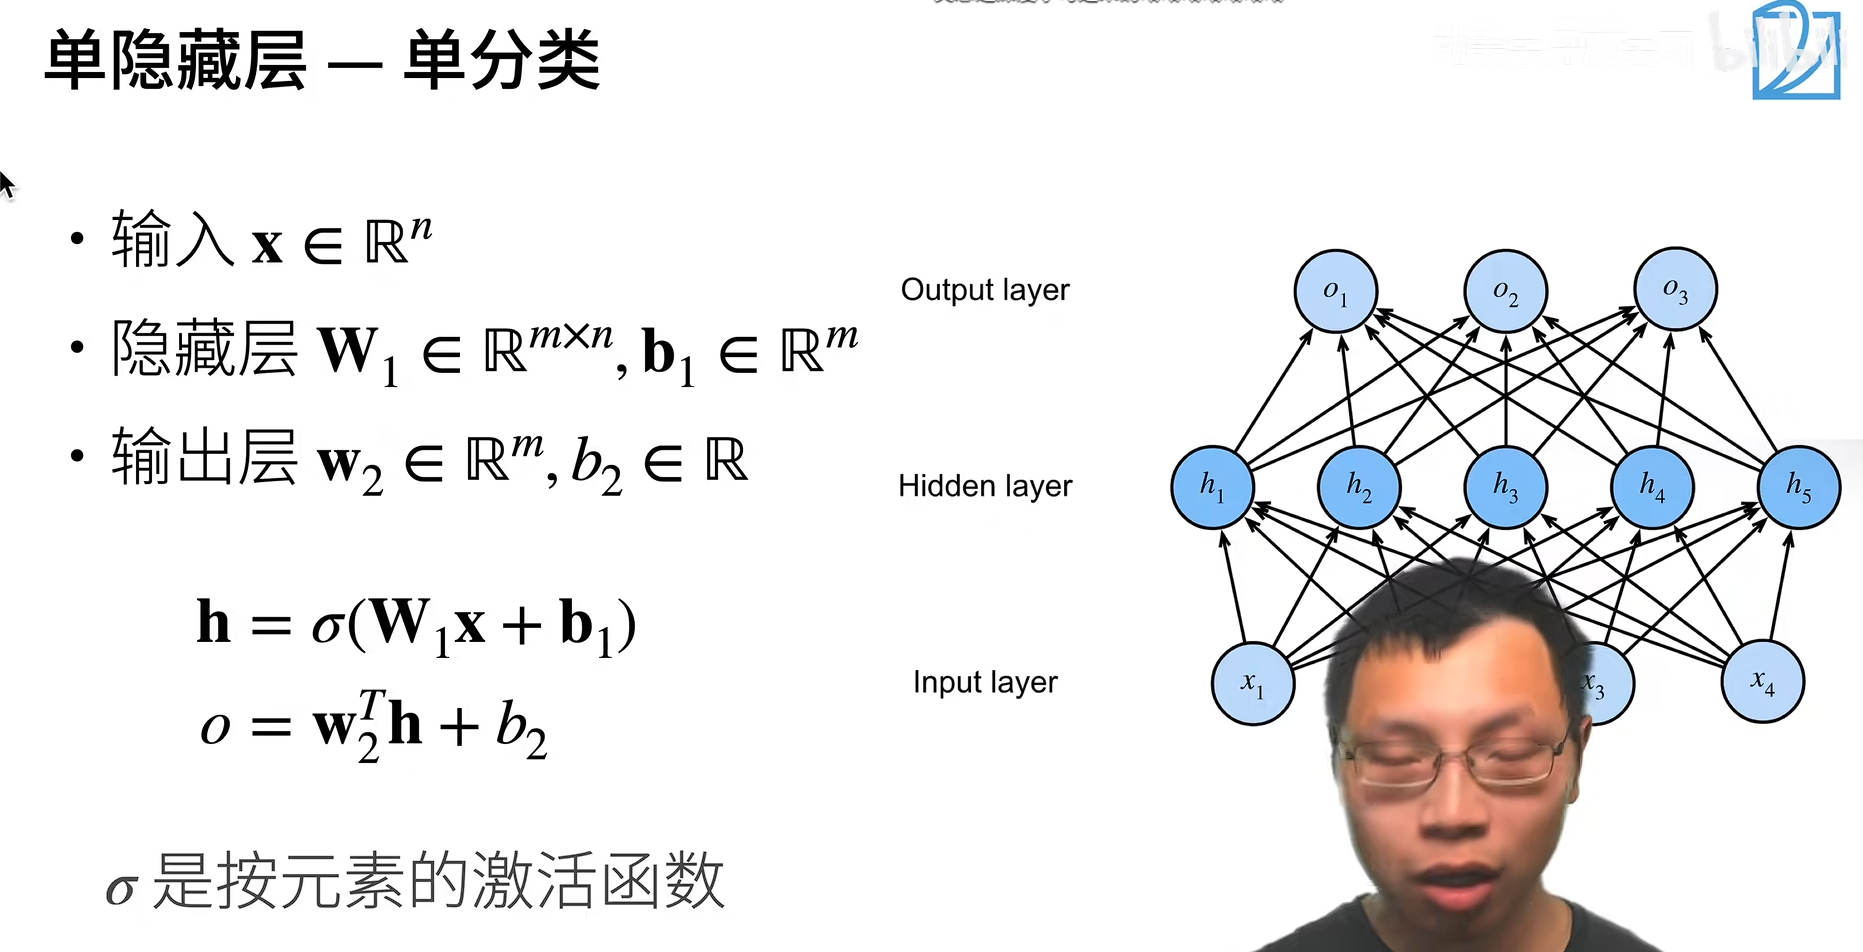
隐藏层大小是超参数  
激活函数是非线性函数  
如果激活函数是线性函数，输出还是线性函数，无法解决问题

Sigmoid 激活函数：
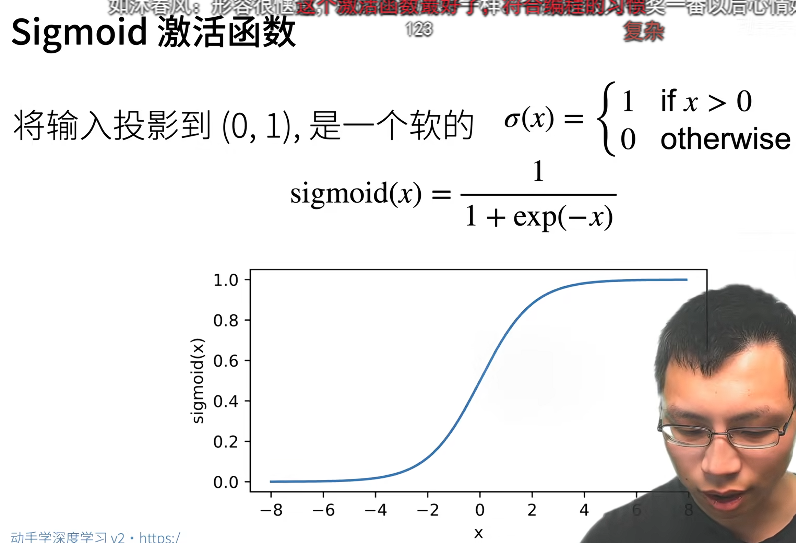

Tanh激活函数：
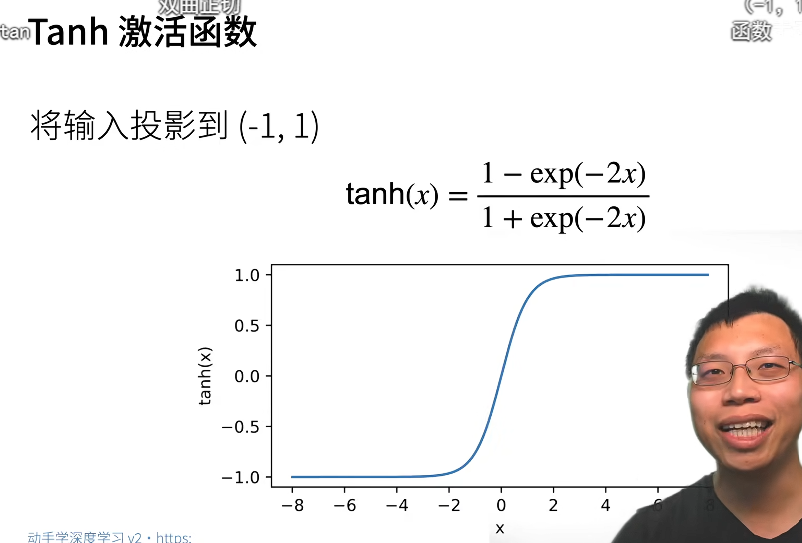

ReLU激活函数：
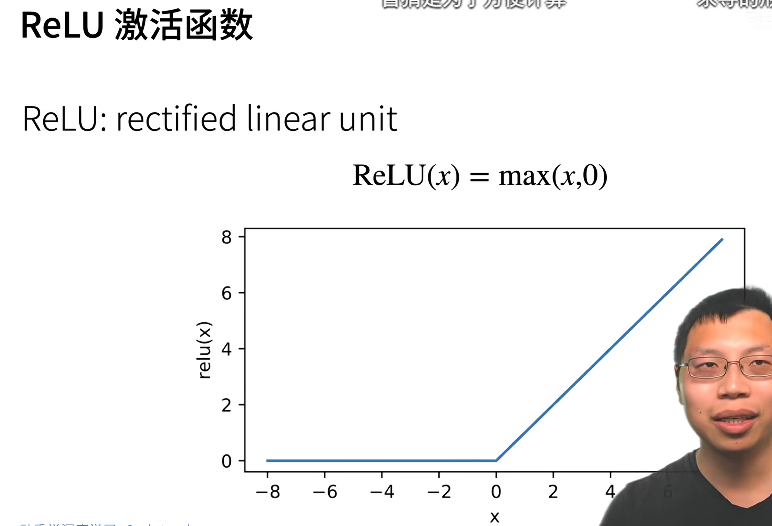

### 多分类
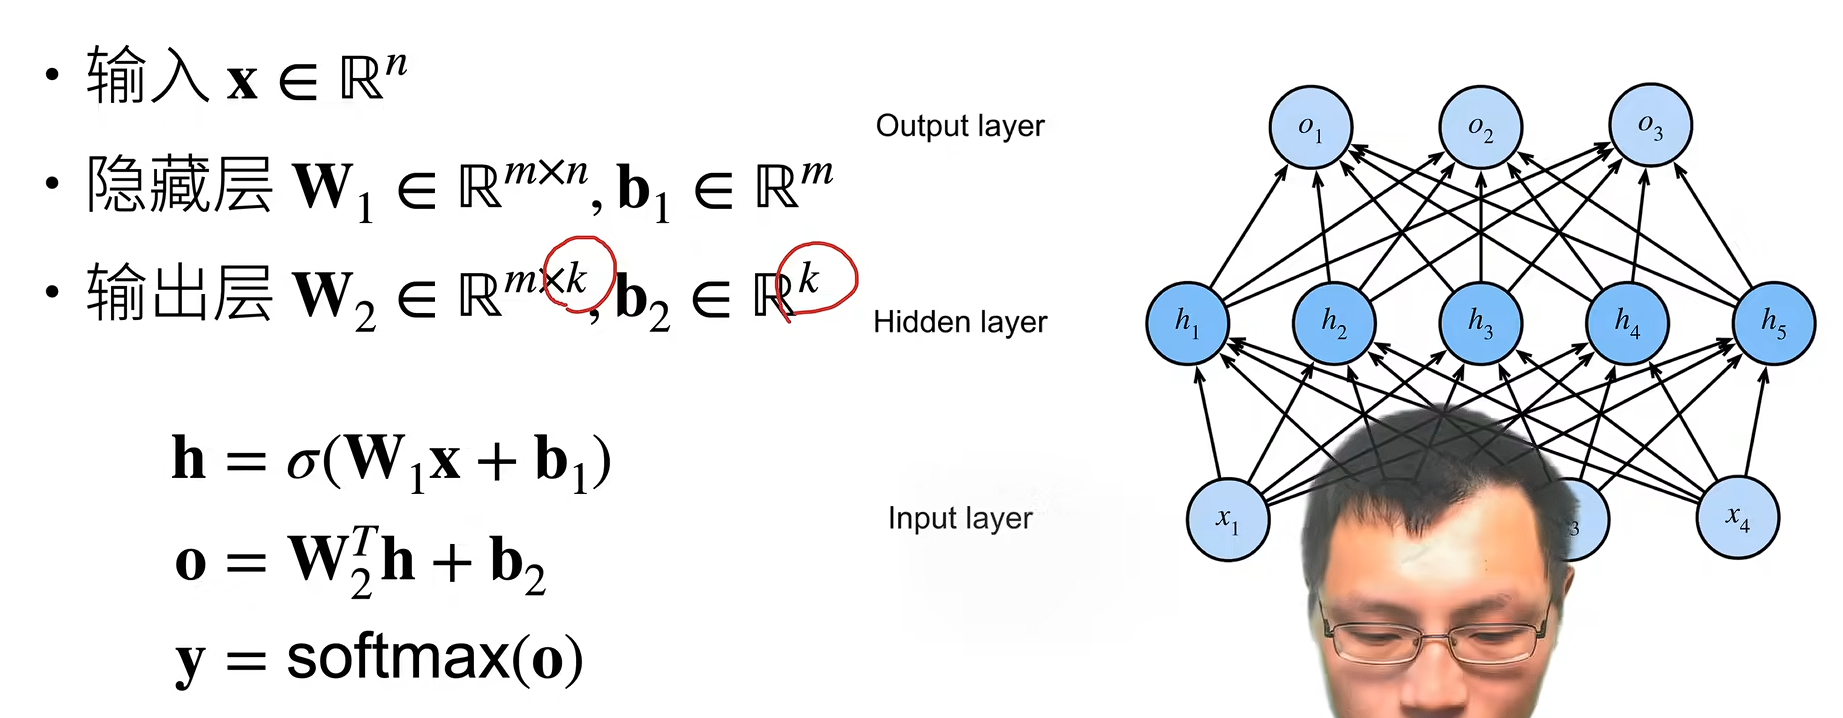
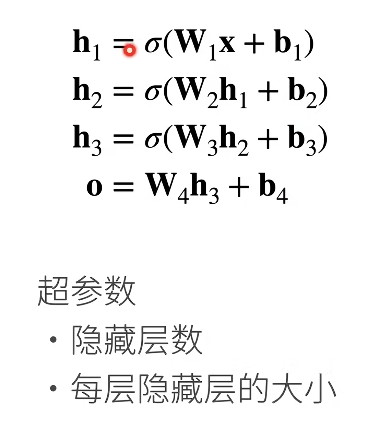

## 多层感知机从零实现

In [11]:
import torch
from torch import nn
from d2l import torch as d2l
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 初始化

In [12]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))
params = [W1, b1, W2, b2]

### 激活函数

In [13]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

### 模型

In [14]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1) # 这⾥“@”代表矩阵乘法
    return (H@W2 + b2)

### 损失函数

In [15]:
loss = nn.CrossEntropyLoss(reduction='none')

### 训练

In [ ]:
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

In [ ]:
d2l.predict_ch3(net, test_iter)

## 多层感知机的简洁实现

### 模型

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
net = nn.Sequential(nn.Flatten(),
nn.Linear(784, 256),
nn.ReLU(),
nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights)

In [ ]:
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)